## **Preparando o ambiente para utilizar o Sparklyr**

### Instalando o Java

O Apache Spark depende de outros sistemas, portanto, antes do Spark é preciso instalar as dependências. Primeiro, deve-se instalar o java

----


In [ ]:
shell_call <- function(command, ...) {
  result <- system(command, intern = TRUE, ...)
  cat(paste0(result, collapse = "\n"))
}

shell_call("ls -lah / | head")

total 456K
drwxr-xr-x   1 root root 4.0K Oct  2 00:20 .
drwxr-xr-x   1 root root 4.0K Oct  2 00:20 ..
lrwxrwxrwx   1 root root    7 Jun 27  2024 bin -> usr/bin
drwxr-xr-x   2 root root 4.0K Apr 18  2022 boot
drwxr-xr-x   1 root root 4.0K Sep 30 13:39 content
-rw-r--r--   1 root root 4.3K Jul 10  2024 cuda-keyring_1.1-1_all.deb
drwxr-xr-x   1 root root 4.0K Sep 30 13:52 datalab
drwxr-xr-x   5 root root  360 Oct  2 00:20 dev
-rwxr-xr-x   1 root root    0 Oct  2 00:20 .dockerenv

In [ ]:
shell_call("apt-get install openjdk-8-jdk-headless -qq > /dev/null")

In [ ]:
# Fazendo download do SPARK
shell_call("wget -q https://dlcdn.apache.org/spark/spark-3.5.7/spark-3.5.7-bin-hadoop3.tgz")

In [ ]:
# Descompactando os arquivos
shell_call("tar xf /content/spark-3.5.7-bin-hadoop3.tgz")

In [ ]:
# Instalando Pacotes Necessários
#install.packages("googledrive")
install.packages("sparklyr")
install.packages("dplyr")
install.packages("e1071")
install.packages("ggplot2")

remotes::install_github("GabeChurch/sparkedatools", upgrade = "never")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘config’, ‘globals’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘proxy’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Installing 4 packages: patchwork, ggstats, GGally, lazyeval

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/RtmpVKvsT3/remotes8c761e374b/GabeChurch-sparkedatools-b44fd0c/DESCRIPTION’ ... OK
* preparing ‘sparkedatools’:
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
Omitted ‘LazyData’ from DESCRIPTION
* building ‘sparkedatools_0.0.0.9000.tar.gz’



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(sparklyr)
library(dplyr)
#' ---
library(e1071) # Para Skewness e Kurtosis
library(sparkedatools)
library(ggplot2)


Attaching package: ‘sparklyr’


The following object is masked from ‘package:stats’:

    filter



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘ggplot2’


The following object is masked from ‘package:e1071’:

    element




In [ ]:
Sys.setenv(SPARK_HOME="/content/spark-3.5.7-bin-hadoop3")

In [ ]:
spark_conn <- spark_connect(master = "local",
                   config=list(spark.sql.warehouse.dir=Sys.getenv("SPARK_HOME")))

In [ ]:
# ------------------------------------
# Baixando os dados
# ----
library(googledrive)
# ID do arquivo
file_id <- "14u4dUuTSYvTOIg4nWPJGai9f8VAXFavy"
destfile <- "base_e-commerce_parquet.zip"
# Baixar arquivo (publico ou com acesso)
drive_download(as_id(file_id), path = destfile, overwrite = TRUE)
# Descompactar zip
unzip(destfile)

File downloaded:

• base_e-commerce_parquet.zip <id: 14u4dUuTSYvTOIg4nWPJGai9f8VAXFavy>

Saved locally as:

• base_e-commerce_parquet.zip



In [ ]:
#' -----------------------
#' Lendo arquivos parquet
#' -----------------------
dados <- spark_read_parquet(spark_conn, name = "base_e-commerce_parquet/database_compras_parquet.parquet" )


In [ ]:
#' -----------------------
#' Lista de data.frames existentes no Spark
#' -----------------------
src_tbls(spark_conn)

[1] "database_compras_parquet_37278fcd_742e_4d15_a596_24ca84778bcc"

In [ ]:
#' -----------------------
#' Verificando número de linhas
#' -----------------------
sdf_dim(dados)
sdf_nrow(dados)
sdf_ncol(dados)


[1] 338185     26

[1] 338185

[1] 26

In [ ]:
#' ------------------------------------
#' Verificando as colunas
#' -----------------
colnames(dados)
sdf_schema(dados)
#' -----------------

[1] "DsOrigem"           "DsCanalVenda"       "DsUnidadeNegocio"  
 [4] "DsTipo"             "NrPedido"           "DhPedido"          
 [7] "NrFilial"           "NrLojista"          "InMarketPlace"     
[10] "InRetira"           "VrVendaLiquida"     "VrDescontoTotal"   
[13] "VrFreteCliente"     "QtItem"             "NrItemLoja"        
[16] "NrItemSite"         "DsItemSite"         "NrDepartamentoSite"
[19] "DsDepartamentoSite" "NrSetorSite"        "DsSetorSite"       
[22] "NrFamiliaSite"      "DsFamiliaSite"      "NrMarcaSite"       
[25] "DsMarcaSite"        "DsSingleId"

$DsOrigem
$DsOrigem$name
[1] "DsOrigem"

$DsOrigem$type
[1] "StringType"


$DsCanalVenda
$DsCanalVenda$name
[1] "DsCanalVenda"

$DsCanalVenda$type
[1] "StringType"


$DsUnidadeNegocio
$DsUnidadeNegocio$name
[1] "DsUnidadeNegocio"

$DsUnidadeNegocio$type
[1] "StringType"


$DsTipo
$DsTipo$name
[1] "DsTipo"

$DsTipo$type
[1] "StringType"


$NrPedido
$NrPedido$name
[1] "NrPedido"

$NrPedido$type
[1] "IntegerType"


$DhPedido
$DhPedido$name
[1] "DhPedido"

$DhPedido$type
[1] "TimestampType"


$NrFilial
$NrFilial$name
[1] "NrFilial"

$NrFilial$type
[1] "IntegerType"


$NrLojista
$NrLojista$name
[1] "NrLojista"

$NrLojista$type
[1] "IntegerType"


$InMarketPlace
$InMarketPlace$name
[1] "InMarketPlace"

$InMarketPlace$type
[1] "BooleanType"


$InRetira
$InRetira$name
[1] "InRetira"

$InRetira$type
[1] "BooleanType"


$VrVendaLiquida
$VrVendaLiquida$name
[1] "VrVendaLiquida"

$VrVendaLiquida$type
[1] "DoubleType"


$VrDescontoTotal
$VrDescontoTotal$name
[1] "VrDescontoTotal"

$VrDescontoTotal$type
[1] "DoubleType"


$VrFreteCliente
$VrFreteCliente$name
[1] "VrFreteCliente"

$VrFreteCliente$type
[1] "DoubleType"


$QtItem
$QtItem$name
[1] "QtItem"

$QtItem$type
[1] "IntegerType"


$NrItemLoja
$NrItemLoja$name
[1] "NrItemLoja"

$NrItemLoja$type
[1] "IntegerType"


$NrItemSite
$NrItemSite$name
[1] "NrItemSite"

$NrItemSite$type
[1] "IntegerType"


$DsItemSite
$DsItemSite$name
[1] "DsItemSite"

$DsItemSite$type
[1] "StringType"


$NrDepartamentoSite
$NrDepartamentoSite$name
[1] "NrDepartamentoSite"

$NrDepartamentoSite$type
[1] "IntegerType"


$DsDepartamentoSite
$DsDepartamentoSite$name
[1] "DsDepartamentoSite"

$DsDepartamentoSite$type
[1] "StringType"


$NrSetorSite
$NrSetorSite$name
[1] "NrSetorSite"

$NrSetorSite$type
[1] "IntegerType"


$DsSetorSite
$DsSetorSite$name
[1] "DsSetorSite"

$DsSetorSite$type
[1] "StringType"


$NrFamiliaSite
$NrFamiliaSite$name
[1] "NrFamiliaSite"

$NrFamiliaSite$type
[1] "IntegerType"


$DsFamiliaSite
$DsFamiliaSite$name
[1] "DsFamiliaSite"

$DsFamiliaSite$type
[1] "StringType"


$NrMarcaSite
$NrMarcaSite$name
[1] "NrMarcaSite"

$NrMarcaSite$type
[1] "IntegerType"


$DsMarcaSite
$DsMarcaSite$name
[1] "DsMarcaSite"

$DsMarcaSite$type
[1] "StringType"


$DsSingleId
$DsSingleId$name
[1] "DsSingleId"

$DsSingleId$type
[1] "StringType"

In [ ]:
#' ----------------------------------------------------------------------------

#' ------------------------------------
#' 3 Análise Exploratória - Descritiva
#' -----------------
colunas_selecionadas <- c('VrVendaLiquida','VrDescontoTotal','VrFreteCliente','QtItem')
#' ------
dados |>
  select(colunas_selecionadas) |>
    sdf_describe()
#' -----------------


# Source:   table<`sparklyr_tmp_45a0660b_5f3e_4f08_ad27_1573e47aeb7d`> [?? x 5]
# Database: spark_connection
  summary VrVendaLiquida     VrDescontoTotal    VrFreteCliente    QtItem        
  <chr>   <chr>              <chr>              <chr>             <chr>         
1 count   338185             338185             338185            338185        
2 mean    873.3852436985125  34.87990191759762  15.35626325828306 1.09994529621…
3 stddev  1127.6857097326094 130.38245321515902 36.41660380059874 0.58722695847…
4 min     0.0                0.0                -4.92             1             
5 max     94950.0            5226.34            2452.89           80            

In [ ]:
#' ------------------------------------
#' Assimetria e Curtose
#' -----------------
dados |>
  sdf_read_column(column = "VrVendaLiquida") |>
    skewness(na.rm = TRUE)
#' -----
dados |>
  sdf_read_column(column = "VrVendaLiquida") |>
    kurtosis(na.rm = TRUE)
#' -----------------


[1] 6.825244

[1] 264.0143

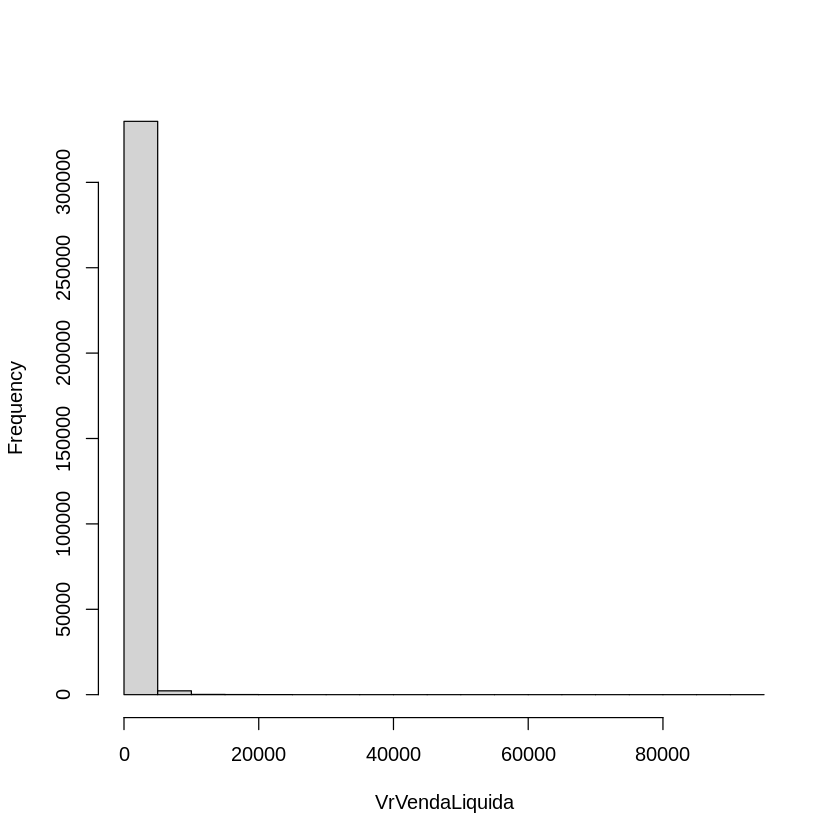

In [ ]:
#' ------------------------------------
#' 3.1 Gerando um histograma
#' -----------------
VrVendaLiquida <- dados |>
          select('VrVendaLiquida') |>
          collect()

hist(VrVendaLiquida$VrVendaLiquida, main = "", xlab="VrVendaLiquida")

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


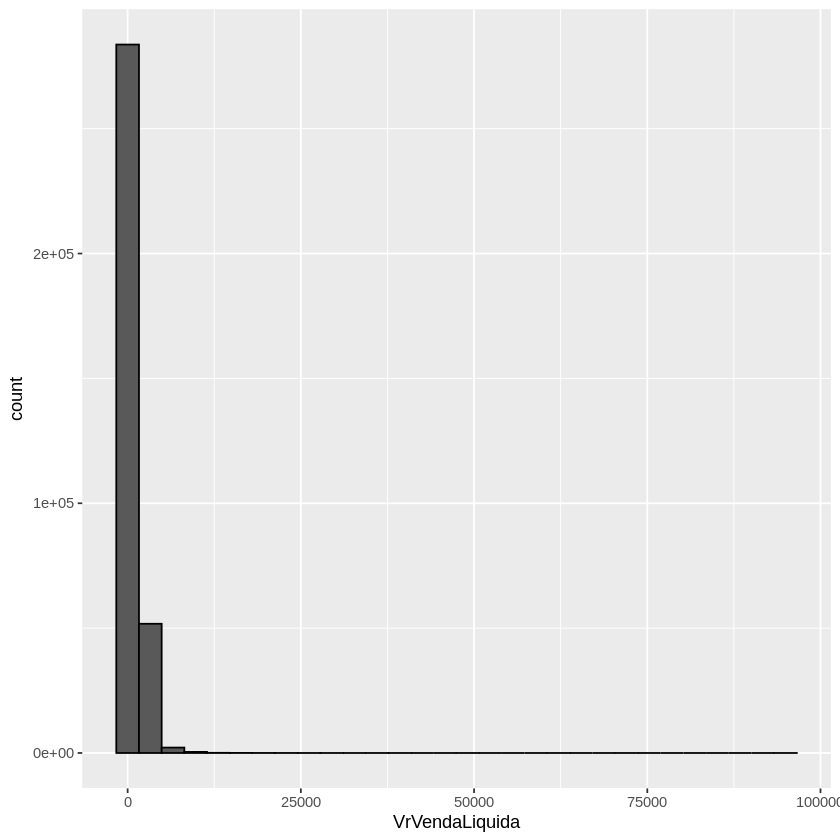

In [ ]:
#' ------
ggplot(data = VrVendaLiquida, aes(x = VrVendaLiquida)) +
  geom_histogram(color="black")

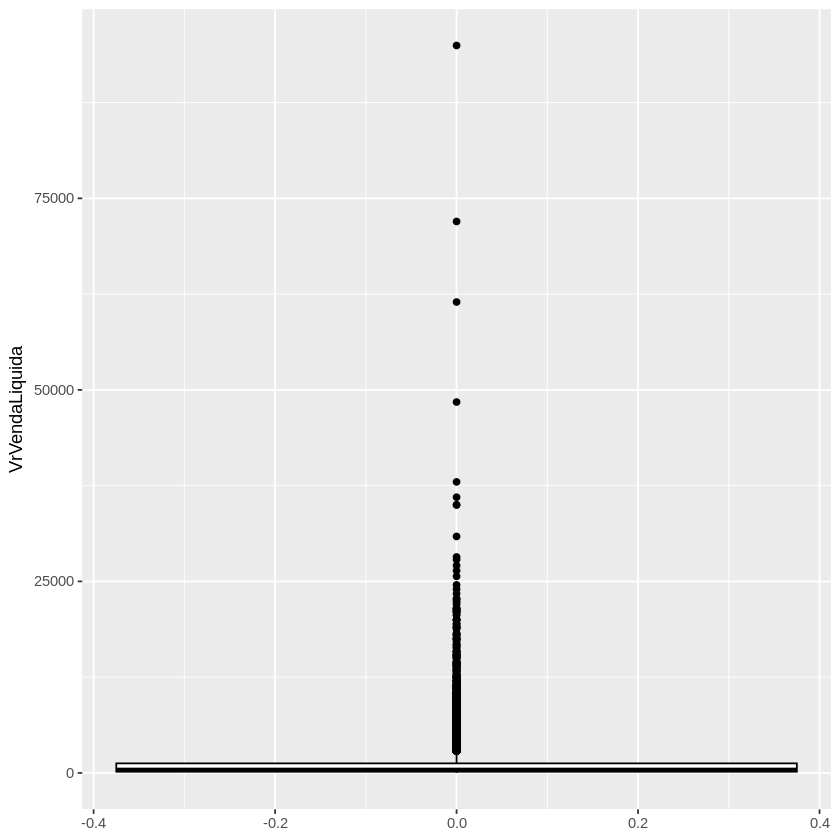

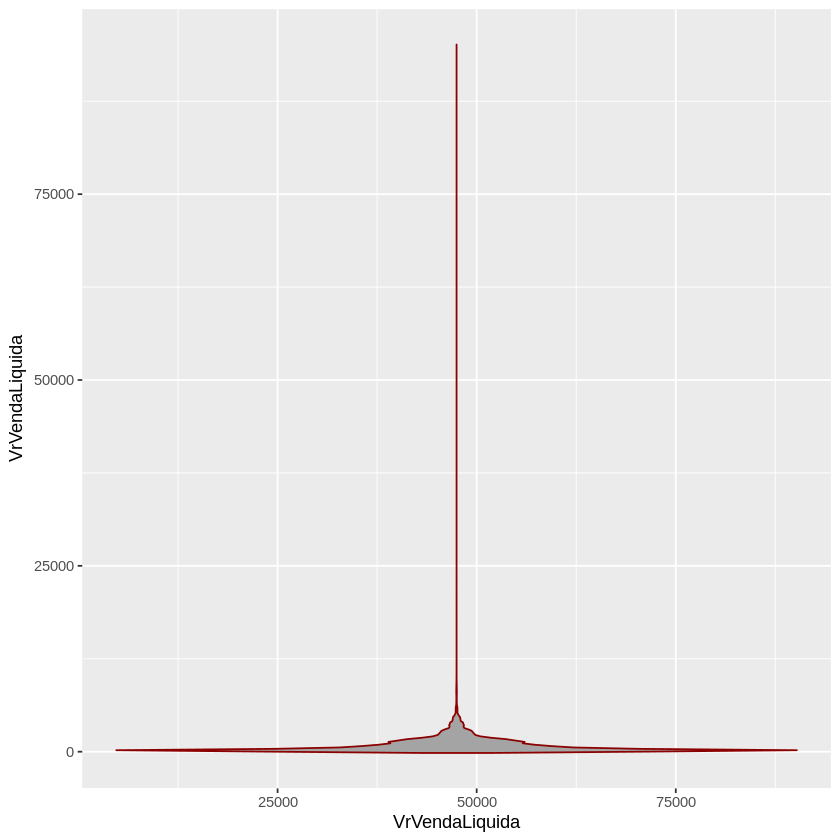

In [ ]:
#' -----------------
#' 3.2 Gerando um BoxPlot
#' -----------------
VrVendaLiquida <- dados |>
          select('VrVendaLiquida') |>
          collect()
#' ------
ggplot(data = VrVendaLiquida, aes(y = VrVendaLiquida)) +
  geom_boxplot(color="black")
#' ------
ggplot(data = VrVendaLiquida, aes(x = VrVendaLiquida, y = VrVendaLiquida)) +
  geom_violin(trim=FALSE, fill='#A4A4A4', color="darkred")
#' ------


In [ ]:
#' ------------------------------------
#' 3.3 Fazendo um agrupamento e gráfico de barras
#' ------------------------------------
total_de_linhas <- sdf_dim(dados)[1]
#' ----------
result <-
  dados |>
    select(c(DsCanalVenda,VrVendaLiquida)) |>
    group_by(DsCanalVenda) |>
    #summarise( list(n = n()))
    summarise_all(
      list(n = ~ n(),
           mean = ~ mean(.),
           min = ~ min(.),
           max = ~ max(.),
           percent = ~ n() / total_de_linhas
           )
      )

result


Warning message:
“Missing values are always removed in SQL aggregation functions.
Use `na.rm = TRUE` to silence this warning
This warning is displayed once every 8 hours.”


# Source:   SQL [?? x 6]
# Database: spark_connection
  DsCanalVenda      n  mean   min    max percent
  <chr>         <dbl> <dbl> <dbl>  <dbl>   <dbl>
1 FT            30338  453.  0.49  6400. 0.0897 
2 MTG            4723  511. 59     2700  0.0140 
3 APP          208604  861.  0    27074. 0.617  
4 SITE          30172 1148.  0    48412  0.0892 
5 PV            30415 1073.  0    94950  0.0899 
6 MOBI          31635  941.  0    21201. 0.0935 
7 TVEN           2298 1151.  0    14056. 0.00680

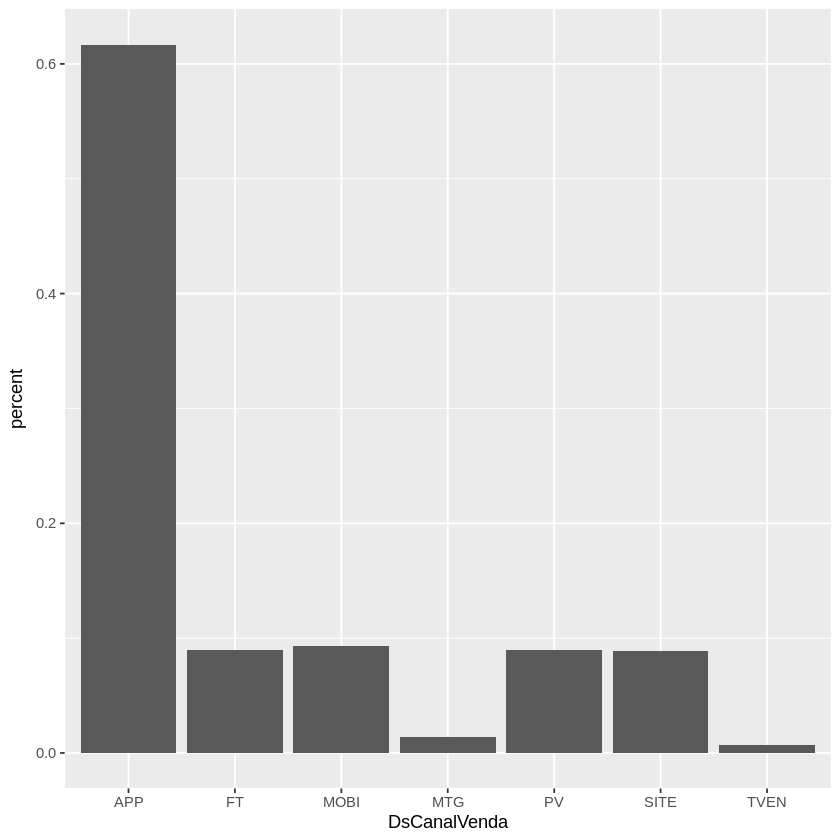

In [ ]:
#' ----------
result |>
  ggplot(aes(x = DsCanalVenda, y = percent)) +
  geom_bar(stat = "identity")


In [ ]:
#' ------------------------------------
#' 3.4 Análise Descritiva Multivariada
#' ------------------------------------

#' ------------------------------------
#' 3.4.1 Correlação
#' ------------------------------------
# Forma 1
features <- c('VrVendaLiquida','VrDescontoTotal','VrFreteCliente','QtItem') #selecionando as colunas
ml_corr(dados, columns = features, method = "pearson") #calculando a correlação

New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`


VrVendaLiquida,VrDescontoTotal,VrFreteCliente,QtItem
<dbl>,<dbl>,<dbl>,<dbl>
1.00000000,0.32127694,0.09764372,0.09143127
0.32127694,1.00000000,0.06850095,0.10715271
0.09764372,0.06850095,1.00000000,0.03972603
0.09143127,0.10715271,0.03972603,1.00000000


In [ ]:
# Forma 2
dados |>
  select(all_of(features)) |>
  ml_corr(method = "pearson")


New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`


VrVendaLiquida,VrDescontoTotal,VrFreteCliente,QtItem
<dbl>,<dbl>,<dbl>,<dbl>
1.00000000,0.32127694,0.09764372,0.09143127
0.32127694,1.00000000,0.06850095,0.10715271
0.09764372,0.06850095,1.00000000,0.03972603
0.09143127,0.10715271,0.03972603,1.00000000


In [ ]:
# List the data frames available in Spark
src_tbls(spark_conn)

[1] "database_compras_parquet_37278fcd_742e_4d15_a596_24ca84778bcc"